# Lab 9.2: CNN Training with Image Augmentation

**Student Name:** Samiullah Khan  
**Registration Number:** 22JZELE0492  
**Course:** Machine Learning Lab  
**Supervisor:** Engr. Irshad Ullah  
**University:** UET Peshawar - Nowshera Campus  

## Lab Overview
This notebook trains a custom CNN for corn leaf image classification using image data generators. It defines the model architecture, compiles it, applies augmentation/rescaling, trains the model with checkpoints, and evaluates classification performance.

## Learning Objectives
- Import the required TensorFlow/Keras and evaluation libraries.
- Define image dataset paths for training, validation, and testing.
- Build and compile a CNN model for image classification.
- Use `ImageDataGenerator` for rescaling and augmentation.
- Train the model and evaluate it using plots, a confusion matrix, and a classification report.

## Section 1: Library Import and Dataset Paths
This section imports Keras tools, plotting libraries, and evaluation metrics, then defines paths for train, validation, and test image folders.


In [1]:
# Import CNN, preprocessing, plotting, array, and evaluation libraries.
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

In [2]:
# Define the checkpoint filename pattern for saving the best validation-loss model.
checkpoints = r'C:\Users\Sami\Documents\MachineLearning\Material\ML\Lab 9\Lab 9\\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

In [3]:
# Define train, validation, and test image dataset folders.
train_dir = r'C:\Users\Sami\Documents\MachineLearning\Material\ML\Lab 9\Lab 9\Computer vision\sectionB\train'
validation_dir = r'C:\Users\Sami\Documents\MachineLearning\Material\ML\Lab 9\Lab 9\Computer vision\sectionB\validation'
test_dir = r'C:\Users\Sami\Documents\MachineLearning\Material\ML\Lab 9\Lab 9\Computer vision\sectionB\test'

## Section 2: CNN Model Architecture
The following cells create and summarize the convolutional neural network used for classification.


In [12]:
# Build a CNN model for image classification.
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(2, activation='sigmoid'))

In [13]:
model.summary()

Model: "sequential_1"

â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”³â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”³â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”“
â”ƒ Layer (type)                    â”ƒ Output Shape           â”ƒ       Param # â”ƒ
â”¡â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â•‡â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â•‡â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”©
â”‚ conv2d_4 (Conv2D)               â”‚ (None, 254, 254, 32)   â”‚           896 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ max_pooling2d_4 (MaxPooling2D)  â”‚ (None, 127, 127, 32)   â”‚             0 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ conv2d_5 (Conv2D)               â”‚ (None, 125, 125, 64)   â”‚        18,496 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ max_pooling2d_5 (MaxPooling2D)  â”‚ (None, 62, 62, 64)     â”‚             0 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ conv2d_6 (Conv2D)               â”‚ (None, 60, 60, 128)    â”‚        73,856 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ max_pooling2d_6 (MaxPooling2D)  â”‚ (None, 30, 30, 128)    â”‚             0 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ conv2d_7 (Conv2D)               â”‚ (None, 28, 28, 128)    â”‚       147,584 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ max_pooling2d_7 (MaxPooling2D)  â”‚ (None, 14, 14, 128)    â”‚             0 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ flatten_1 (Flatten)             â”‚ (None, 25088)          â”‚             0 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ dropout_1 (Dropout)             â”‚ (None, 25088)          â”‚             0 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ dense_2 (Dense)                 â”‚ (None, 512)            â”‚    12,845,568 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚

 Total params: 13,087,426 (49.92 MB)

 Trainable params: 13,087,426 (49.92 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Compile the model with categorical cross-entropy and RMSprop.
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)

In [15]:
# Create augmented training batches and rescaled validation batches.
train_datagen = ImageDataGenerator(
                                    rescale=1./255,
                                    rotation_range=40,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range=0.2,
                                    zoom_range=0.2,
                                    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
                                                    train_dir,
                                                    target_size=(256, 256),
                                                    batch_size=32,
                                                    class_mode='categorical')

validation_generator = test_datagen.flow_from_directory(
                                                        validation_dir,
                                                        target_size=(256, 256),
                                                        batch_size=32,
                                                        class_mode='categorical')

Found 345 images belonging to 2 classes.
Found 252 images belonging to 4 classes.


## Section 3: Data Generators, Augmentation, and Training
This section prepares image generators, applies rescaling/augmentation, sets checkpoints, and trains the CNN model.


In [16]:
# Create rescaled image generators without additional augmentation.
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32,class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(validation_dir,target_size=(256, 256),batch_size=32,class_mode='categorical')

Found 345 images belonging to 2 classes.
Found 252 images belonging to 4 classes.


In [17]:
# Save only the best model checkpoint according to validation loss.
EpochCheckpoint = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
callbacks = [EpochCheckpoint]

In [18]:
# Display the class mapping and number of detected classes.
print(train_generator.class_indices)
print(train_generator.num_classes)

{'Cercospora': 0, 'common_rust': 1}
2


In [19]:
# Train the model using the image generators and checkpoint callback.
model_history = model.fit(train_generator,
                         validation_data =validation_generator,
                         steps_per_epoch=train_generator.n//train_generator.batch_size,
                         validation_steps = validation_generator.n//validation_generator.batch_size,
                         epochs = 4,
                         callbacks = callbacks)

Epoch 1/4
10/10 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 3s/step - accuracy: 0.8026 - loss: 0.4745

ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 4), output.shape=(None, 2)

In [ ]:
model_history.history

{'accuracy': [0.5212500095367432,
  0.7350000143051147,
  0.7762500047683716,
  0.8137500286102295,
  0.824999988079071,
  0.8600000143051147,
  0.8731250166893005,
  0.8837500214576721,
  0.9024999737739563,
  0.9068750143051147,
  0.9225000143051147,
  0.9287499785423279,
  0.9275000095367432,
  0.9431250095367432,
  0.9462500214576721,
  0.953125,
  0.9493749737739563,
  0.9474999904632568,
  0.9612500071525574,
  0.9649999737739563,
  0.9637500047683716,
  0.9781249761581421,
  0.9775000214576721,
  0.9737499952316284,
  0.9837499856948853,
  0.9793750047683716,
  0.9893749952316284,
  0.9868749976158142,
  0.987500011920929,
  0.9900000095367432,
  0.9912499785423279,
  0.9900000095367432,
  0.9912499785423279,
  0.9912499785423279,
  0.9943749904632568,
  0.9906250238418579,
  0.9925000071525574,
  0.9956250190734863,
  0.9937499761581421,
  0.9937499761581421],
 'loss': [1.0973082780838013,
  0.6110215187072754,
  0.4939495325088501,
  0.4100242257118225,
  0.378933310508728,
  

## Section 4: Model Evaluation
The final cells evaluate model performance using plots, predictions, confusion matrix, and classification report.


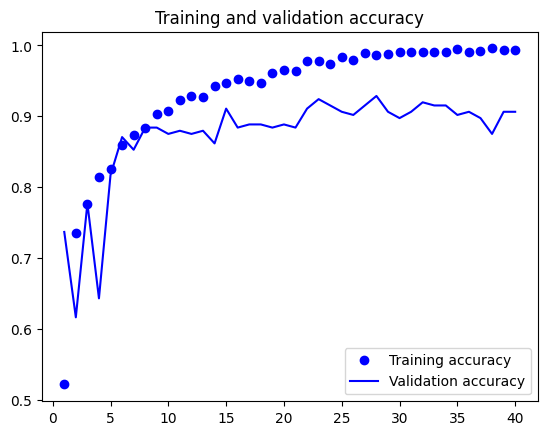

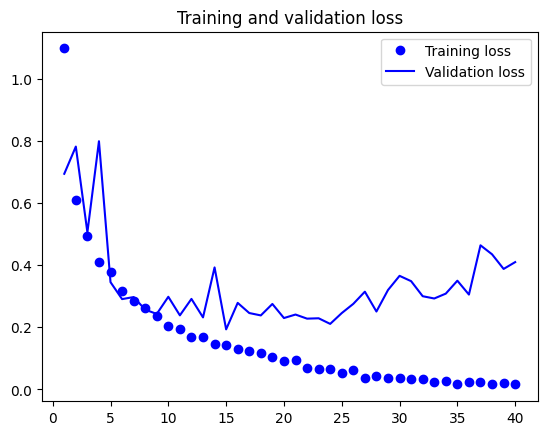

In [ ]:
# Plot and save the training/validation accuracy and loss curves.
acc = model_history.history['accuracy']
val_acc = model_history.history['val_accuracy']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure()
plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.savefig(r'Z:\University\8th Semester\ML Lab\Lab 9\model_Accuracy.png')

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.savefig(r'Z:\University\8th Semester\ML Lab\Lab 9\model_Loss.png')

plt.show()

Found 200 images belonging to 4 classes.
7/7 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 5s 637ms/step


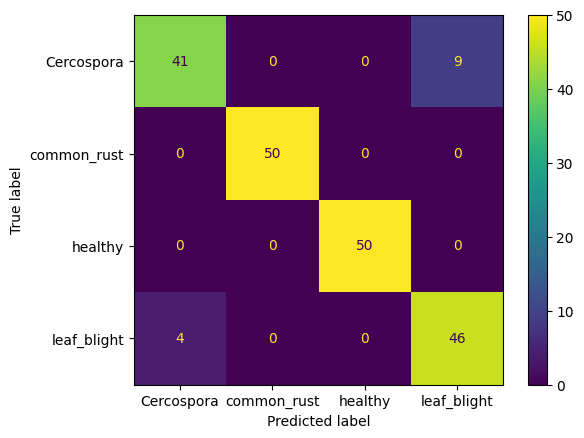

In [ ]:
# Load a saved model, predict test classes, and display the confusion matrix.
model = load_model(r'Z:\University\8th Semester\ML Lab\Lab 9\E1-cp-0015-loss0.19.h5')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=32, shuffle=False, class_mode='categorical')
label=test_generator.labels
preds=model.predict(test_generator)
pred = np.argmax(preds, axis = 1)
cm = confusion_matrix(label, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Cercospora', 'common_rust','healthy', 'leaf_blight'])
disp.plot()
plt.show()
#plt.savefig(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\confusion_matrics.jpg')

In [ ]:
# Print precision, recall, F1-score, and support for each class.
print(classification_report(label, pred, target_names=['Cercospora', 'common_rust','healthy', 'leaf_blight']))

              precision    recall  f1-score   support

  Cercospora       0.91      0.82      0.86        50
 common_rust       1.00      1.00      1.00        50
     healthy       1.00      1.00      1.00        50
 leaf_blight       0.84      0.92      0.88        50

    accuracy                           0.94       200
   macro avg       0.94      0.93      0.93       200
weighted avg       0.94      0.94      0.93       200



## Final Conclusion
In this lab, a CNN model was trained using image augmentation and evaluated on corn leaf image classes. This workflow connects dataset preparation, augmentation, model training, and classification evaluation.

## Submitted By
**Student Name:** Samiullah Khan  
**Registration Number:** 22JZELE0492  
**Course:** Machine Learning Lab  
**Supervisor:** Engr. Irshad Ullah  
**University:** UET Peshawar - Nowshera Campus